In [149]:
import pandas as pd
import geopandas as gpd
import plotly.express as px


In [176]:
#df_adulte = pd.read_csv('Resultats/Excels/patients_FR_geocoded_adultes_clinique.csv',sep=";",dtype={'codepost':str})

#df_adulte = df_adulte.drop('Unnamed: 0', axis=1)

df_pat_revenu = pd.read_csv('data/data_cleaned/patients_FR_adulte_clinique_revenus_chomage.csv',sep=";",dtype={'codepost':str})

id_dcd = pd.read_excel('../geocodeur/from_hegp/data/data_octobre_2023/dcd_pseudo.xlsx')
dcd = id_dcd['pseudo_provisoire'].to_list()

# REVIEW AVEC CLEMENCE 

In [177]:
df_adulte = pd.read_csv("Resultats/Excels/patients_FR_geocoded_adultes_clinique.csv",sep=";", dtype={"codepost":str})


In [178]:
len(df_adulte)

57878

In [180]:
df_cim = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/CODECIM_updated.csv.xlsx")
df_cim.drop('Unnamed: 3', axis=1, inplace=True)

correspondance = df_cim.set_index('topo_initiale_cim10')['Proposition_Clémence_1'].to_dict()

df_adulte['pathologie'] = df_adulte['topo_initiale_cim10'].map(correspondance)
df_adulte = df_adulte[~df_adulte['pseudo_provisoire'].isin(dcd)]

print(df_adulte.columns)
print(len(df_adulte))


Index(['Unnamed: 0.1', 'Unnamed: 0', 'pseudo_provisoire', 'adresse',
       'codepost', 'nom_commune_postal', 'requete', 'x', 'y', 'score',
       'trust_score', 'street', 'city', 'pc_city', 'ic_city', 'code_dept',
       'dept', 'reg', 'address', 'address_has_num_init',
       'address_has_num_geoloc', 'same_city', 'hostel', 'hosted',
       'date_geoloc', 'geometry', 'CODE_IRIS', 'CODE_EPCI', 'CODE_DEPT',
       'index_right', 'ID_GEOFLA', 'CODE_DEPT_RIGHT', 'NOM_DEPT', 'CODE_CHF',
       'NOM_CHF', 'X_CHF_LIEU', 'Y_CHF_LIEU', 'X_CENTROID', 'Y_CENTROID',
       'CODE_REG', 'NOM_REG', 'patient_sexe', 'date_naissance', 'centre',
       'ageaudiag', 'cancernum', 'date_diag', 'topo_initiale_cim10',
       'topo_initialelib', 'pathologie'],
      dtype='object')
57878
374


In [183]:
#df_adulte = df_pat_revenu 
df_adulte = df_adulte[~df_adulte['pseudo_provisoire'].isin(dcd)]
len(df_adulte)

45429

In [156]:
df_sous_traitement = pd.read_excel("../geocodeur/from_hegp/data/data_octobre_2023/w_ttt_pseudo.xlsx")
# df_clinique = df_clinique[~df_clinique['pseudo_provisoire'].isin(dcd)]
id_traitement = df_sous_traitement['pseudo_provisoire'].tolist()

id_dcd = set(id_dcd)
id_traite = set(id_traitement)

id_comm = id_dcd.intersection(id_traite)

len(id_comm)

0

In [170]:
len(df_adulte)

45429

In [171]:
df_adulte = df_adulte[~df_adulte['pseudo_provisoire'].isin(dcd)]
len(df_adulte)

45429

In [172]:
# df_adulte['patient_sexe'].unique()

df_homme = df_adulte[df_adulte['patient_sexe']=="M"]
df_femme = df_adulte[df_adulte['patient_sexe']=="F"]

# print(f'Nombre hommes adultes: {len(df_homme), (len(df_homme)/len(df_adulte))*100}')
# print(f'Nombre femmes adultes: {len(df_femme),(len(df_femme)/len(df_adulte))*100}')
# print(len(df_homme)+len(df_femme))
# print(len(df_adulte))


df_homme_idf = df_homme[df_homme['INSEE_REG']==11]
df_femme_idf = df_femme[df_femme['INSEE_REG']==11]
df_adulte_idf = df_adulte[df_adulte['INSEE_REG']==11]

# print(f'Nombre hommes adultes en IDF: {len(df_homme_idf),(len(df_homme_idf)/len(df_adulte))*100}')
# print(f'Nombre femmes adultes en IDF: {len(df_femme_idf),(len(df_femme_idf)/len(df_adulte))*100}')
# print(len(df_adulte_idf),(len(df_adulte_idf)/len(df_adulte))*100)

df_f_sein = df_femme[df_femme['topo_initiale_cim10']=='C50']
df_sein = df_adulte[df_adulte['topo_initiale_cim10']=='C50']
df_h_sein = df_homme[df_homme['topo_initiale_cim10']=='C50']
print(len(df_f_sein),(len(df_f_sein)/len(df_adulte))*100)
print(len(df_h_sein),(len(df_h_sein)/len(df_adulte))*100)
print(len(df_sein),(len(df_sein)/len(df_adulte))*100)

liste_gyn = ['C51','C52','C53','C54','C55','C56','C57','C58']

df_f_gyn = df_femme[df_femme['topo_initiale_cim10'].isin(liste_gyn)]
df_gyn = df_adulte[df_adulte['topo_initiale_cim10'].isin(liste_gyn)]
df_h_gyn = df_homme[df_homme['topo_initiale_cim10'].isin(liste_gyn)]
print("-------------------------------------------")
print(len(df_f_gyn),(len(df_f_gyn)/len(df_adulte))*100)
print(len(df_h_gyn),(len(df_h_gyn)/len(df_adulte))*100)
print(len(df_gyn),(len(df_gyn)/len(df_adulte))*100)

thorax=['C33','C34','C37','C38','C39','C45']

df_f_thorax = df_femme[df_femme['topo_initiale_cim10'].isin(thorax)]
df_h_thorax = df_homme[df_homme['topo_initiale_cim10'].isin(thorax)]
df_thorax = df_adulte[df_adulte['topo_initiale_cim10'].isin(thorax)]
print("-------------------------------------------")
print(len(df_f_thorax),(len(df_f_thorax)/len(df_adulte))*100)
print(len(df_h_thorax),(len(df_h_thorax)/len(df_adulte))*100)
print(len(df_thorax),(len(df_thorax)/len(df_adulte))*100)

27821 61.24061722688151
142 0.31257566752514915
27963 61.55319289440666
-------------------------------------------
1912 4.208765326113276
1 0.002201237095247529
1913 4.2109665632085225
-------------------------------------------
678 1.4924387505778247
795 1.7499834907217855
1473 3.2424222412996104


## Analyse nos patients par quartile de revenu et de taux de chomage

In [160]:
# df_revenu_quart = pd.DataFrame(df_adulte.groupby(['patient_sexe','quartile_revenu']).size())

# df_revenu_quart.to_excel('revenu_par_genre_non_dcd.xlsx')

# df_chomage_quart =pd.DataFrame(df_adulte.groupby(['patient_sexe','quartile_chomage']).size())

# df_chomage_quart.to_excel('chomage_par_genre_non_dcd.xlsx')


df_chomage_quart =pd.DataFrame(df_f_gyn.groupby('quartile_chomage').size())
df_chomage_quart.to_excel('chomage_gyn_f.xlsx')

# df_revenu_quart =pd.DataFrame(df_f_gyn.groupby('quartile_revenu').size())
# df_revenu_quart.to_excel('excels/revenu_gyn_f.xlsx')






## Visualisation heatmap

In [161]:
df = df_homme
df.loc[:,'patient_count'] = 1


gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y)).set_crs(epsg=4326)#.to_crs(epsg=2154) add ()


In [162]:

# Create a heatmap using plotly express
fig = px.density_mapbox(df, lat='y', lon='x', z='patient_count', 
                        radius=7,
                        center=dict(lat=47, lon=2), # Center on Paris
                        zoom=5
                        )

fig.update_layout(
    width=1000,  # Width of the figure
    height=800,  # Height of the figure
    mapbox=dict(
        #zoom=10,
        style="carto-positron",  # Map style (you can also use "open-street-map", "carto-positron", etc.)
    ),
    margin={"r":30, "t":30, "l":30, "b":30},  # Remove margins for a cleaner look
    coloraxis_colorbar=dict(
        title='Number of Patients',
        tickvals=[0, 15000, 30000, 45000, 60000],
        ticktext=['0', '15k', '30k', '45k', '60k']
    ),
    title ="Distribution des patients masculins Français traités à l'Institut Curie"
)


# Display the figure (this won't work in this environment, but the code is provided for reference)
fig.show()

# fig.write_html("H:/canc_air/data/heatmap_figure.html")


In [163]:
import plotly.figure_factory as ff
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



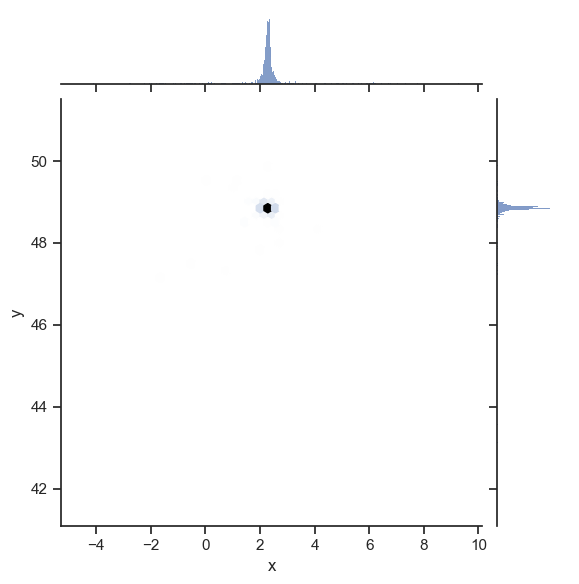

In [164]:

sns.set_theme(style="ticks")

# rs = np.random.RandomState(11)
# x = rs.gamma(2, size=1000)
# y = -.5 * x + rs.normal(size=1000)

sns.jointplot(x=df.x, y=df.y, kind="hex")#, color="#4CB391")

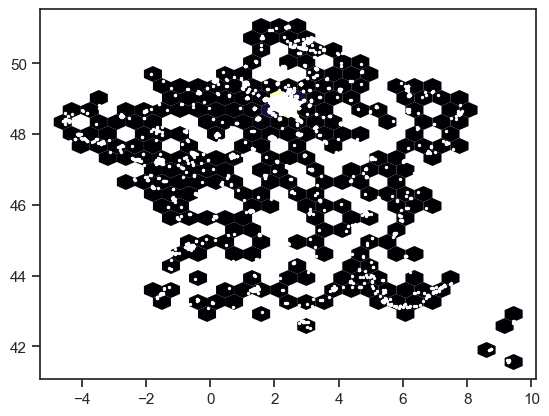

In [165]:
plt.hexbin(df.x,df.y,gridsize=25, mincnt=1, edgecolors="none", cmap="inferno")
plt.scatter(df.x,df.y, s=2, c="white")
plt.show()

In [166]:

# # px.set_mapbox_access_token(open(".mapbox_token").read())
# # df = px.data.carshare()

# fig = ff.create_hexbin_mapbox(
#     data_frame=df, lat="y", lon="x",
#     nx_hexagon=10, opacity=0.9, #labels={"color": "Point Count"},
# )
# # fig.update_layout(margin=dict(b=0, t=0, l=0, r=0))
# fig.show()